In [1]:
from sklearn.datasets import load_iris

In [3]:
df = load_iris()
X = df.data
y = df.target

In [6]:
df.feature_names , df.target_names

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [8]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state = 42 , stratify = y)

In [9]:
X_train ,X_test , y_train , y_test

(array([[4.4, 2.9, 1.4, 0.2],
        [4.9, 2.5, 4.5, 1.7],
        [6.8, 2.8, 4.8, 1.4],
        [4.9, 3.1, 1.5, 0.1],
        [5.5, 2.5, 4. , 1.3],
        [6.3, 2.5, 5. , 1.9],
        [5.6, 2.7, 4.2, 1.3],
        [6.3, 2.8, 5.1, 1.5],
        [7.7, 3. , 6.1, 2.3],
        [7.7, 3.8, 6.7, 2.2],
        [7.6, 3. , 6.6, 2.1],
        [6. , 2.9, 4.5, 1.5],
        [5. , 2. , 3.5, 1. ],
        [5.8, 2.7, 4.1, 1. ],
        [5.8, 2.6, 4. , 1.2],
        [4.7, 3.2, 1.6, 0.2],
        [5.1, 3.8, 1.5, 0.3],
        [6.7, 2.5, 5.8, 1.8],
        [6.4, 3.1, 5.5, 1.8],
        [5.4, 3.4, 1.5, 0.4],
        [6.3, 2.5, 4.9, 1.5],
        [5.1, 3.8, 1.6, 0.2],
        [7.9, 3.8, 6.4, 2. ],
        [5. , 3. , 1.6, 0.2],
        [5.5, 2.4, 3.7, 1. ],
        [6.3, 2.9, 5.6, 1.8],
        [6.4, 2.7, 5.3, 1.9],
        [5. , 3.4, 1.6, 0.4],
        [5.6, 2.8, 4.9, 2. ],
        [5. , 3.5, 1.3, 0.3],
        [5.1, 3.7, 1.5, 0.4],
        [6.1, 2.8, 4. , 1.3],
        [6.1, 3. , 4.6, 1.4],
        [5

In [10]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100 , random_state=42)
model.fit(X_train , y_train)

RandomForestClassifier(random_state=42)

In [11]:
model.predict(X_test)

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [12]:
len(model.estimators_)

100

In [13]:
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

[Text(0.4444444444444444, 0.9285714285714286, 'petal length (cm) <= 2.7\ngini = 0.665\nsamples = 77\nvalue = [44, 39, 37]\nclass = setosa'),
 Text(0.3333333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 29\nvalue = [44, 0, 0]\nclass = setosa'),
 Text(0.38888888888888884, 0.8571428571428572, 'True  '),
 Text(0.5555555555555556, 0.7857142857142857, 'petal width (cm) <= 1.65\ngini = 0.5\nsamples = 48\nvalue = [0, 39, 37]\nclass = versicolor'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.4444444444444444, 0.6428571428571429, 'sepal width (cm) <= 2.25\ngini = 0.093\nsamples = 26\nvalue = [0, 39, 2]\nclass = versicolor'),
 Text(0.2222222222222222, 0.5, 'petal length (cm) <= 4.5\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]\nclass = versicolor'),
 Text(0.3333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.666

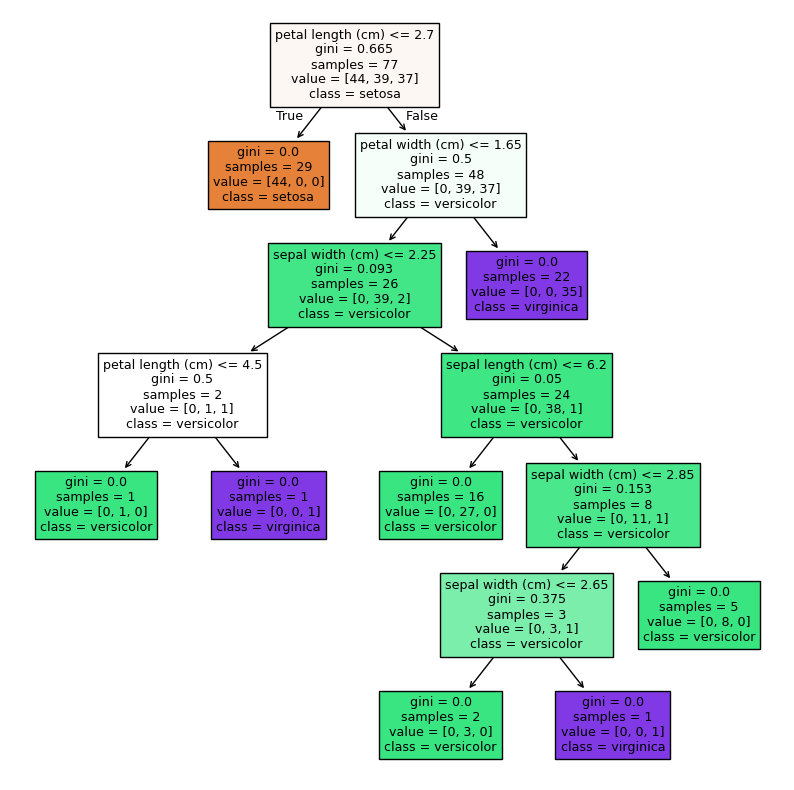

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plot_tree(model.estimators_[91] , feature_names=df.feature_names , class_names=df.target_names , filled = True)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_test,y_pred)
test_accuracy

0.9

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [28]:
from sklearn.metrics import classification_report
a = classification_report( y_test,y_pred,target_names=df.target_names)
a

'              precision    recall  f1-score   support\n\n      setosa       1.00      1.00      1.00        10\n  versicolor       0.82      0.90      0.86        10\n   virginica       0.89      0.80      0.84        10\n\n    accuracy                           0.90        30\n   macro avg       0.90      0.90      0.90        30\nweighted avg       0.90      0.90      0.90        30\n'

In [29]:
results = []
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n,random_state=42)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train,train_pred)
    test_acc = accuracy_score(y_test,test_pred)
    results.append([n, train_acc, test_acc])

    print(f"Trees: {n} | "f"Train: {train_acc:.4f} | "f"Test: {test_acc:.4f}")

Trees: 10 | Train: 1.0000 | Test: 0.9667
Trees: 50 | Train: 1.0000 | Test: 0.9000
Trees: 100 | Train: 1.0000 | Test: 0.9000
Trees: 200 | Train: 1.0000 | Test: 0.9000


In [30]:
for depth in [2, 3, 5, None]:
    model = RandomForestClassifier(n_estimators=100,max_depth=depth,random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train,model.predict(X_train))
    test_acc = accuracy_score(y_test,model.predict(X_test))
    print(f"Depth: {depth} | "f"Train: {train_acc:.4f} | "f"Test: {test_acc:.4f}")

Depth: 2 | Train: 0.9750 | Test: 0.9000
Depth: 3 | Train: 0.9833 | Test: 0.9667
Depth: 5 | Train: 1.0000 | Test: 0.9333
Depth: None | Train: 1.0000 | Test: 0.9000


In [31]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier( max_depth=3, random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [32]:
dt_accuracy = accuracy_score(y_test,y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {test_accuracy:.4f}")

Decision Tree Accuracy: 0.9667
Random Forest Accuracy: 0.9000
